In [71]:
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
stock=pd.read_csv("stock_cleaned.csv")

In [44]:
le= LabelEncoder()
stock["signal"]=le.fit_transform(stock["signal"])
stock=pd.get_dummies(stock,columns=["ticker","sector"])

In [45]:
stock=stock.drop(columns=["date"])

In [46]:
stock=stock.astype({col : int for col in stock.select_dtypes(bool).columns})

In [47]:
stock.columns

Index(['open', 'high', 'low', 'close', 'volume', 'daily_return_pct',
       'pct_change', 'ma_7', 'ma_30', 'ma_50', 'rsi', 'macd', 'volatility_10d',
       'signal', 'next_day_return', 'ticker_AAPL', 'ticker_AMZN',
       'ticker_GOOGL', 'ticker_JNJ', 'ticker_JPM', 'ticker_MSFT',
       'ticker_NFLX', 'ticker_TSLA', 'sector_Automotive', 'sector_E-Commerce',
       'sector_Entertainment', 'sector_Finance', 'sector_Healthcare',
       'sector_Technology'],
      dtype='object')

In [48]:
x=stock[['open', 'high', 'low', 'close', 'volume', 'daily_return_pct',
       'pct_change', 'ma_7', 'ma_30', 'ma_50', 'rsi', 'macd', 'volatility_10d',
        'next_day_return', 'ticker_AAPL', 'ticker_AMZN',
       'ticker_GOOGL', 'ticker_JNJ', 'ticker_JPM', 'ticker_MSFT',
       'ticker_NFLX', 'ticker_TSLA', 'sector_Automotive', 'sector_E-Commerce',
       'sector_Entertainment', 'sector_Finance', 'sector_Healthcare',
       'sector_Technology']]
y=stock['signal']

In [49]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [50]:
model=RandomForestClassifier(n_estimators=200,max_depth=3,random_state=42,class_weight={0:1, 1:5, 2:1} )
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Accuracy : ", accuracy_score(y_test,y_pred))

Accuracy :  0.8301435406698564


In [51]:
print("Train Accuracy:", accuracy_score(y_train, model.predict(x_train)))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Train Accuracy: 0.8604790419161676
Test Accuracy: 0.8301435406698564


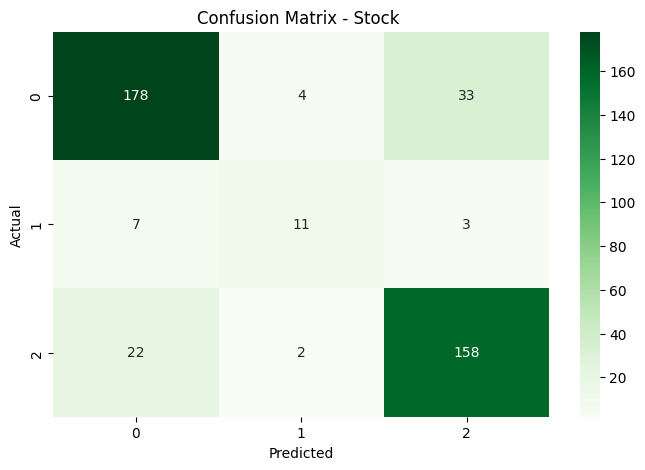

              precision    recall  f1-score   support

           0       0.86      0.83      0.84       215
           1       0.65      0.52      0.58        21
           2       0.81      0.87      0.84       182

    accuracy                           0.83       418
   macro avg       0.77      0.74      0.75       418
weighted avg       0.83      0.83      0.83       418



In [52]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,5))
sns.heatmap(cm,annot=True,fmt="d",cmap='Greens')
plt.title('Confusion Matrix - Stock ')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


print(classification_report(y_test,y_pred))

In [54]:
importances= model.feature_importances_

/var/folders/6m/qm4yytdd1ql5xd4tkcvf2d880000gn/T/ipykernel_892/1209215437.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importances",y="Features",data=feature_df.head(15),palette="viridis")


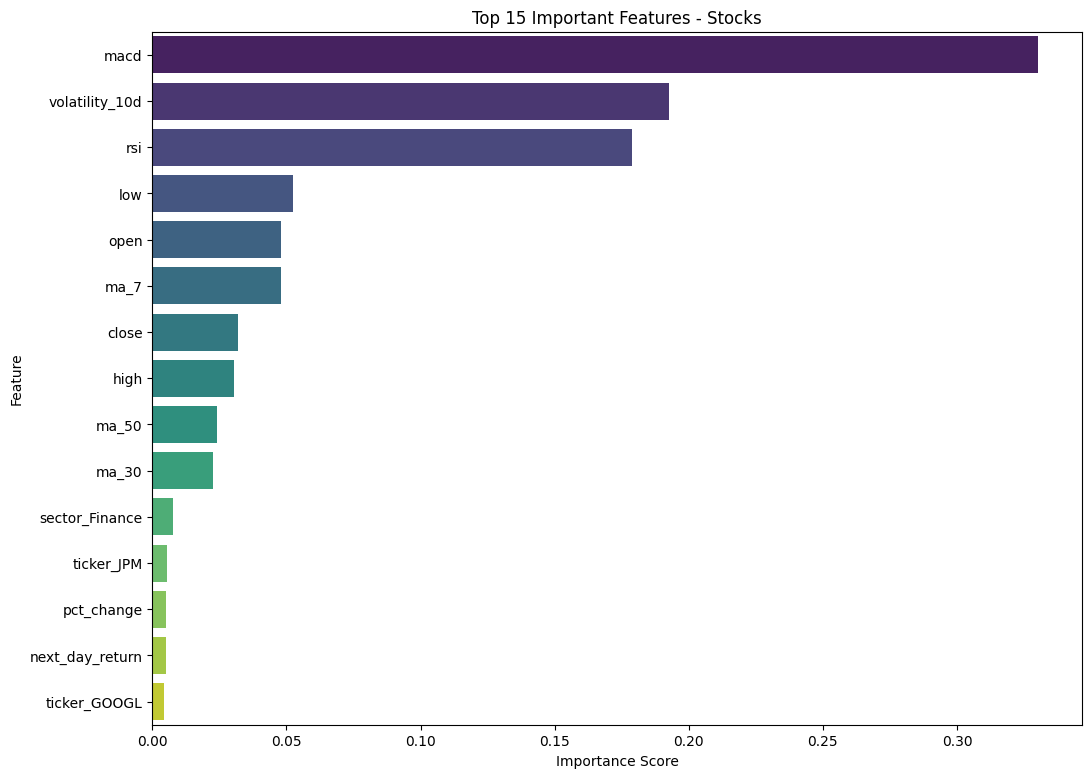

In [69]:
feature_df=pd.DataFrame({
    "Features": x.columns,
    "Importances": importances
})
feature_df=feature_df.sort_values("Importances",ascending=False)
plt.figure(figsize=(12,9))
sns.barplot(x="Importances",y="Features",data=feature_df.head(15),palette="viridis")
plt.title('Top 15 Important Features - Stocks')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [ ]:
pickle.dump(model,open("STOCK_model.pkl","wb"))
print("Model Saved")